# EuroSAT baseline classifier

Pipeline sanity-check: train/val split, data loading, training loop, metrics.

Note: EuroSAT gives one label per whole image (classification), not pixel masks. This is *not* the final segmentation model — it just proves the training pipeline works before moving to real Sentinel-2 + ESA WorldCover segmentation data.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import torch
from torch import nn

from helpers.dataloaders import load_eurosat_data, build_dataloaders
from models.resnet18_classifier_builder import build_resnet18_classifier
from training.engine import Engine
from training.evaluate import evaluate_classifier, draw_confusion_matrix


DATA_DIR = Path.cwd().parent / "data"

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


### 1/ Load EuroSat data (preprocessed with a transform)


In [3]:

full_dataset = load_eurosat_data()

classes = full_dataset.classes

print(f"{len(full_dataset)} images, {len(classes)} classes: {classes}")

27000 images, 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


###  2/ Split the dataset into training, validation and test DataLoader


In [4]:

BATCH_SIZE = 64
SEED_NUM = 42
train_loader, val_loader, test_loader = build_dataloaders(full_dataset, BATCH_SIZE, 0.7, 0.15, SEED_NUM)


###  3/ Load the pretrained ResNet18 model and modify the final fully connected layer to match the number of classes in EuroSAT
#### TODO : maybe use a different model, like EfficientNet, or a custom CNN, or a ViT (Vision Transformer) model


In [5]:
# 3/ Load the pretrained ResNet18 model and modify the final fully connected layer to match the number of classes in EuroSAT
# TODO : maybe use a different model, like EfficientNet, or a custom CNN, or a ViT (Vision Transformer) model

model = build_resnet18_classifier(num_classes=len(classes), device=device)

# 7/ Define the loss function and optimizer
# CrossEntropyLoss combine en une seule opération LogSoftmax + NLLLoss (Negative Log-Likelihood Loss)
# -> parfait pour classification multi-classe, mono-label (1 image = 1 classe)
#
# Alternatives :
# - nn.NLLLoss                          -> meme chose mais il faut appliquer soi-meme LogSoftmax avant
# - nn.BCEWithLogitsLoss                -> si multi-label (une image pourrait avoir plusieurs classes en meme temps)
# - CrossEntropyLoss(weight=...)        -> si les classes etaient desequilibrees (pondere chaque classe)
# - CrossEntropyLoss(label_smoothing=.1)-> reduit la sur-confiance du modele, ameliore la generalisation
# - Focal Loss (pas native PyTorch)     -> utile si classes rares/difficiles (frequent en teledetection)
# - Dice Loss / Dice+CE                 -> pour la future segmentation d'images (ex: segmenter les routes, les batiments, etc.)
loss_fn = nn.CrossEntropyLoss()

# TODO Try with another learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

### 4/ Train the model


In [6]:
# Run the model train 

EPOCHS = 5

training_engine = Engine(device, loss_fn, optimizer)

training_engine.display_info()

history = training_engine.train_model(model, train_loader, val_loader, EPOCHS)



device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Epoch 1/5 - Train Loss: 0.3224, Train Acc: 0.8980 - Val Loss: 0.1222, Val Acc: 0.9607
Epoch 2/5 - Train Loss: 0.0739, Train Acc: 0.9768 - Val Loss: 0.1163, Val Acc: 0.9598
Epoch 3/5 - Train Loss: 0.0431, Train Acc: 0.9869 - Val Loss: 0.1279, Val Acc: 0.9600
Epoch 4/5 - Train Loss: 0.0285, Train Acc: 0.9913 - Val Loss: 0.1333, Val Acc: 0.9615
Epoch 5/5 - Train Loss: 0.0298, Train Acc: 0.9911 - Val Loss: 0.1564, Val Acc: 0.9585


#### Show loss function and accuracy curves

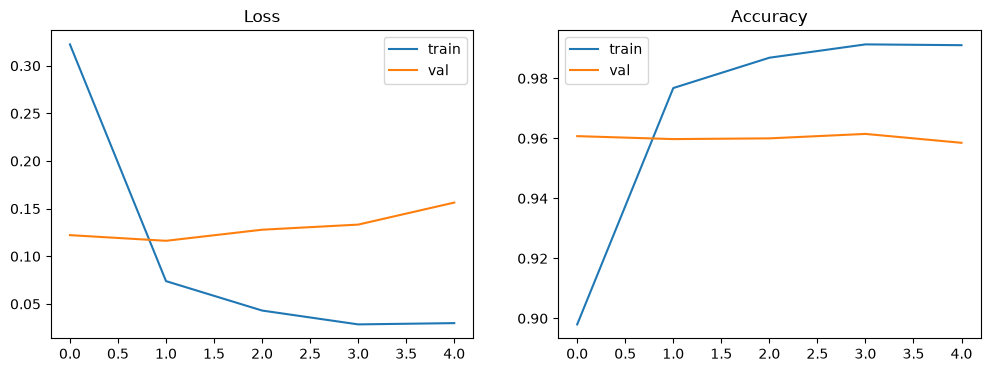

In [7]:
# 10/ Plot the training and validation loss and accuracy curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.show()

## Test set evaluation

#### Evaluation of the trained model on the "test" split set


In [12]:

all_preds, all_labels = evaluate_classifier(model, test_loader, device, classes, print=True)

draw_confusion_matrix(all_labels, all_preds, classes)


TypeError: evaluate_classifier() got an unexpected keyword argument 'print'

### Save the trained weight in a binary to reuse it

In [ ]:
CHECKPOINT_DIR = Path.cwd().parent / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
# model.state_dict() -> retourne un dictionnaire Python contenant tous les poids appris du réseau (les tenseurs de model.fc, des couches convolutives ResNet18, etc.), sans l'architecture elle-même.
torch.save(model.state_dict(), CHECKPOINT_DIR / "resnet18_eurosat.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'resnet18_eurosat.pth'}")

Saved checkpoint to /Users/erizzolio/Work/Alyra/SOLSCAN/data/checkpoints/resnet18_eurosat.pth
